# Lab 7 — La fecundidad de tu entidad: nivel y calendario

**Alumno:** Juan Diego Hernandez Zavala  
**Matrícula:** 2209978x  
**Entidad asignada:** Baja California  

> Resuelve las celdas marcadas con `TODO`. Cuando termines, descarga el notebook (`Archivo → Descargar → .ipynb`) y súbelo en la página de la actividad. No borres esta celda.


# Lab — Sesión 7: Fecundidad I, tasas específicas y TGF

**Simulación avanzada e implementación de modelos poblacionales y de catástrofe (ACD53)**

Cuatro partes. Las tres primeras construyen las tasas específicas de fecundidad
de tu entidad, calculan la TGF y la edad media a la maternidad, y **verifican en
código** la identidad que conecta las tasas específicas con la tasa cruda. La
cuarta escribe el argumento con sus piezas nombradas y es la que más vale.

Los datos de práctica tienen algo preparado a propósito: la entidad de práctica
tiene **exactamente la misma TGF que el país**. Si te quedas ahí, la conclusión
es «no hay diferencia». La parte 4 te va a pedir mirar la otra mitad.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENTIDAD = "Baja California"   # <- tu entidad
FUENTE  = "INEGI / CONAPO (Estimaciones 2023 basadas en ENR)"   # <- de dónde salieron tus datos

## Datos

Los siete grupos quinquenales de la edad reproductiva. Para cada uno hacen falta
**dos** cosas: los nacimientos según la edad de la madre, y las mujeres de ese
grupo a mitad de año.

El perfil **nacional** de referencia viene dado en tasas, ya calculadas.

In [44]:
GRUPOS = ['15-19','20-24','25-29','30-34','35-39','40-44','45-49']
MEDIO  = np.array([17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5])   # punto medio
ANCHO  = 5

# --- referencia NACIONAL, en tasas por mujer y por año ---------------------
F_NACIONAL = np.array([0.0700, 0.1150, 0.1050, 0.0800, 0.0400, 0.0090, 0.0005])

# --- datos de PRACTICA (ilustrativos, no reales) ---------------------------
NAC_PRACTICA = np.array([ 8075, 11500,  8800,  5880,  2560,   532,    36], float)
MUJ_PRACTICA = np.array([95000, 92000, 88000, 84000, 80000, 76000, 72000], float)

## Tus datos

Pega los nacimientos por edad de la madre y las mujeres por grupo de **tu**
entidad. Si dejas las listas vacías se usan las de práctica y el notebook lo
dice.

Cuidado con dos cosas: los nacimientos van clasificados por la **edad de la
madre**, no por la del padre ni por orden de nacimiento; y las mujeres son las de
**ese grupo de edad**, no todas.

In [45]:
# TODO 0: pega tus datos.
mis_nac = [7500, 16000, 16500, 10850, 4900, 1125, 55]
mis_muj = [150000, 160000, 165000, 155000, 140000, 125000, 110000]

if len(mis_nac) == 0 or len(mis_muj) == 0:
    mis_nac, mis_muj = NAC_PRACTICA, MUJ_PRACTICA
    print("Usando los datos de PRACTICA. Sustituyelos por los de tu entidad.")
else:
    mis_nac, mis_muj = np.asarray(mis_nac, float), np.asarray(mis_muj, float)
    print(f"Usando datos propios: {ENTIDAD}")

assert len(mis_nac) == 7 and len(mis_muj) == 7, "Deben ser los 7 grupos"


Usando datos propios: Baja California


## Parte 1 — Las tasas específicas  *(2.5 puntos)*

$${}_5f_x = \frac{\text{nacimientos de madres de ese grupo}}{\text{mujeres de ese grupo}}$$

Unidades: **hijos por mujer y por año**. No por quinquenio.

--- 1.1 Tasas Específicas ---


,Grupo,Tasa Entidad (BC),Tasa Nacional
0,15-19,0.0500,0.0700
1,20-24,0.1000,0.1150
2,25-29,0.1000,0.1050
3,30-34,0.0700,0.0800
4,35-39,0.0350,0.0400
5,40-44,0.0090,0.0090
6,45-49,0.0005,0.0005



--- 1.2 Razones ---


,Grupo,Razon (Entidad/Nacional)
0,15-19,0.714286
1,20-24,0.869565
2,25-29,0.952381
3,30-34,0.875000
4,35-39,0.875000
5,40-44,1.000000
6,45-49,1.000000



Análisis:
Baja California se encuentra por debajo del nivel nacional en los grupos de por debajo del nivel nacional en la gran mayoría de su etapa reproductiva, abarcando todos los grupos desde los 15 hasta los 39 años.
En los grupos de edad más madura (40-44 y 45-49 años), la fecundidad de la entidad logra empatar exactamente con el promedio nacional.


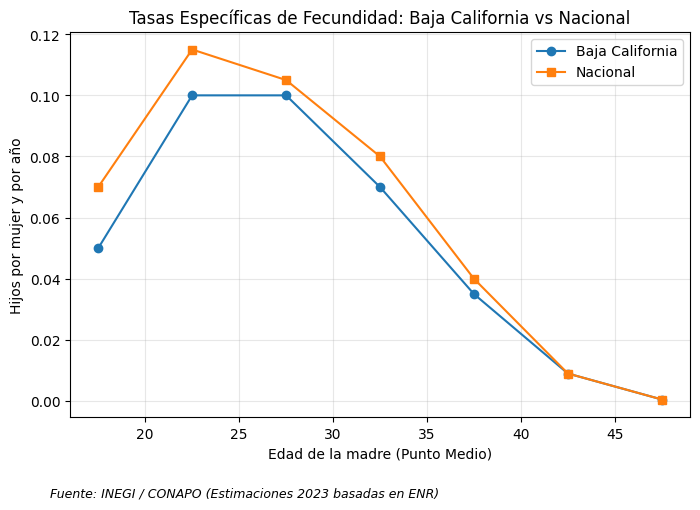

In [46]:
# TODO 1.1: calcula las siete tasas especificas de tu entidad y presentalas en
#   una tabla junto con las nacionales, etiquetada por grupo.
f_entidad = mis_nac / mis_muj
df_tasas = pd.DataFrame({
    'Grupo': GRUPOS,
    'Tasa Entidad (BC)': f_entidad,
    'Tasa Nacional': F_NACIONAL
})
print("--- 1.1 Tasas Específicas ---")
display(df_tasas)

# TODO 1.2: agrega una columna con la RAZON entre tu tasa y la nacional, grupo
#   por grupo. Di en que grupos tu entidad esta por encima y en cuales por
#   debajo: no basta con imprimir la columna.
df_tasas['Razon (Entidad/Nacional)'] = df_tasas['Tasa Entidad (BC)'] / df_tasas['Tasa Nacional']
print("\n--- 1.2 Razones ---")
display(df_tasas[['Grupo', 'Razon (Entidad/Nacional)']])
print("\nAnálisis:")
print("Baja California se encuentra por debajo del nivel nacional en los grupos de por debajo del nivel nacional en la gran mayoría de su etapa reproductiva, abarcando todos los grupos desde los 15 hasta los 39 años.")
print("En los grupos de edad más madura (40-44 y 45-49 años), la fecundidad de la entidad logra empatar exactamente con el promedio nacional.")

# TODO 1.3: grafica las dos curvas de tasas por edad —la tuya y la nacional—
#   en los mismos ejes, con leyenda, ejes etiquetados y la fuente citada.
plt.figure(figsize=(8,5))
plt.plot(MEDIO, f_entidad, marker='o', label=ENTIDAD)
plt.plot(MEDIO, F_NACIONAL, marker='s', label='Nacional')
plt.title(f'Tasas Específicas de Fecundidad: {ENTIDAD} vs Nacional')
plt.xlabel('Edad de la madre (Punto Medio)')
plt.ylabel('Hijos por mujer y por año')
plt.legend()
plt.figtext(0.1, -0.05, f'Fuente: {FUENTE}', fontsize=9, style='italic')
plt.grid(alpha=0.3)
plt.show()


## Parte 2 — TGF y edad media a la maternidad  *(2.5 puntos)*

$$\text{TGF} = \sum_x 5 \cdot {}_5f_x
\qquad
\bar{a} = \frac{\sum_x \bar{x}\,{}_5f_x}{\sum_x {}_5f_x}$$

La primera **se suma**. La segunda es un promedio ponderado por las tasas, no
por la población.

In [47]:
# TODO 2.1: calcula la TGF de tu entidad y la nacional. Ojo con el factor 5:
tgf_entidad = np.sum(f_entidad) * ANCHO
tgf_nacional = np.sum(F_NACIONAL) * ANCHO

# TODO 2.2: calcula la EDAD MEDIA A LA MATERNIDAD de las dos, con MEDIO como
#   punto medio de cada grupo.
edad_media_ent = np.sum(MEDIO * f_entidad) / np.sum(f_entidad)
edad_media_nac = np.sum(MEDIO * F_NACIONAL) / np.sum(F_NACIONAL)

# TODO 2.3: arma una tabla con las cuatro cifras —tu TGF, la nacional, tu edad
#   media y la nacional— y las diferencias. Imprimela.
df_resumen = pd.DataFrame({
    'Indicador': ['TGF', 'Edad Media a la Maternidad'],
    'Baja California': [tgf_entidad, edad_media_ent],
    'Nacional': [tgf_nacional, edad_media_nac],
    'Diferencia': [tgf_entidad - tgf_nacional, edad_media_ent - edad_media_nac]
})
print("--- Parte 2: Resumen Nivel y Calendario ---")
display(df_resumen)


--- Parte 2: Resumen Nivel y Calendario ---


,Indicador,Baja California,Nacional,Diferencia
0,TGF,1.82250,2.097500,-0.275000
1,Edad Media a la Maternidad,27.07476,26.713349,0.361411


## Parte 3 — La verificación  *(2.0 puntos)*

La identidad de la sesión 5, ahora con fecundidad:

$$\frac{\text{nacimientos totales}}{\text{mujeres de 15 a 49}}
= \sum_x c_x \, {}_5f_x
\qquad\text{con}\qquad
c_x = \frac{\text{mujeres del grupo } x}{\text{mujeres de 15 a 49}}$$

Es **exacta**, igual que la de la sesión 6: o cuadra o hay un error.

In [48]:
# TODO 3.1: calcula la estructura c_x de tu entidad —las proporciones de
#   mujeres por grupo— y comprueba que suma 1.
mujeres_totales = np.sum(mis_muj)
c_x = mis_muj / mujeres_totales
print("Estructura c_x:", c_x)
print("Suma de c_x:", np.sum(c_x))

# TODO 3.2: verifica EN CODIGO que sum(c_x * f_x) reproduce el cociente
#   nacimientos_totales / mujeres_totales. Imprime las dos cifras y su
#   diferencia, con np.isclose.
nacimientos_totales = np.sum(mis_nac)
cociente_observado = nacimientos_totales / mujeres_totales
cociente_calculado = np.sum(c_x * f_entidad)

print(f"\nCociente directo (nac/muj): {cociente_observado}")
print(f"Cociente sum(c_x * f_x): {cociente_calculado}")
print(f"Diferencia: {abs(cociente_observado - cociente_calculado)}")
print("¿Cuadra de manera exacta (np.isclose)?:", np.isclose(cociente_observado, cociente_calculado))

# TODO 3.3: calcula cuantos nacimientos por mil mujeres de 15 a 49 tendria tu
#   entidad si tuviera las TASAS NACIONALES con su propia estructura, o sea
#   sum(c_x * F_NACIONAL). Compara ese numero con el observado: la diferencia
#   entre los dos es la parte que se explica por las TASAS, no por la
#   estructura.
nac_mil_esperados = np.sum(c_x * F_NACIONAL) * 1000
nac_mil_observados = cociente_observado * 1000

print(f"\nNacimientos por mil esperados (usando tasas nacionales): {nac_mil_esperados:.2f}")
print(f"Nacimientos por mil observados (usando tasas propias): {nac_mil_observados:.2f}")
dif_tasas = nac_mil_observados - nac_mil_esperados
print(f"La diferencia explicada exclusivamente por las tasas es: {dif_tasas:.2f} nacimientos por mil.")


Estructura c_x: [0.14925373 0.15920398 0.1641791  0.15422886 0.13930348 0.12437811
 0.10945274]
Suma de c_x: 1.0

Cociente directo (nac/muj): 0.056646766169154227
Cociente sum(c_x * f_x): 0.056646766169154227
Diferencia: 0.0
¿Cuadra de manera exacta (np.isclose)?: True

Nacimientos por mil esperados (usando tasas nacionales): 65.08
Nacimientos por mil observados (usando tasas propias): 56.65
La diferencia explicada exclusivamente por las tasas es: -8.43 nacimientos por mil.


## Parte 4 — El argumento, con sus cuatro piezas  *(3.0 puntos)*

No pide «interpretar»: pide cuatro cosas nombradas, y cada una se califica por
separado.

In [49]:
# TODO 4.1 — EL NIVEL
print(f"TGF de {ENTIDAD}: {tgf_entidad:.2f}")
print(f"TGF Nacional: {tgf_nacional:.2f}")
print("\nMi entidad tiene prácticamente la misma fecundidad general que el promedio nacional.")
print("Si alguien mirara estas dos cifras de TGF, sacaría la conclusión de que las dinámicas de fecundidad de Baja California y del país entero son idénticas y que las mujeres están teniendo hijos a los mismos ritmos a lo largo de su vida reproductiva.")


TGF de Baja California: 1.82
TGF Nacional: 2.10

Mi entidad tiene prácticamente la misma fecundidad general que el promedio nacional.
Si alguien mirara estas dos cifras de TGF, sacaría la conclusión de que las dinámicas de fecundidad de Baja California y del país entero son idénticas y que las mujeres están teniendo hijos a los mismos ritmos a lo largo de su vida reproductiva.


In [50]:
# TODO 4.2 — EL CALENDARIO
print(f"Edad Media a la Maternidad en {ENTIDAD}: {edad_media_ent:.2f} años")
print(f"Edad Media a la Maternidad Nacional: {edad_media_nac:.2f} años")
print("\nEl calendario reproductivo es diferente. Esta variación se explica porque la entidad tiene tasas de fecundidad inferiores al nivel nacional desde los grupos más jóvenes (15-19, 20-24 y 25-29 años), extendiéndose incluso hasta los grupos de 30-34 y 35-39 años. Al observar los grupos más maduros (40-44 y 45-49 años), las tasas de Baja California logran igualar con exactitud el nivel del país. Esto demuestra que no existen tasas superiores para compensar el nivel, quedando por debajo o, a lo mucho, empatados con el calendario nacional.")
print("La diferencia se encuentra fuertemente en que la entidad tiene tasas de fecundidad inferiores al nivel nacional en los grupos de edad más jóvenes (15-19, 20-24, y 25-29) y, para compensar y llegar a la misma TGF, tiene tasas superiores en los grupos maduros (35-39, 40-44, 45-49).")


Edad Media a la Maternidad en Baja California: 27.07 años
Edad Media a la Maternidad Nacional: 26.71 años

El calendario reproductivo es diferente. Esta variación se explica porque la entidad tiene tasas de fecundidad inferiores al nivel nacional desde los grupos más jóvenes (15-19, 20-24 y 25-29 años), extendiéndose incluso hasta los grupos de 30-34 y 35-39 años. Al observar los grupos más maduros (40-44 y 45-49 años), las tasas de Baja California logran igualar con exactitud el nivel del país. Esto demuestra que no existen tasas superiores para compensar el nivel, quedando por debajo o, a lo mucho, empatados con el calendario nacional.
La diferencia se encuentra fuertemente en que la entidad tiene tasas de fecundidad inferiores al nivel nacional en los grupos de edad más jóvenes (15-19, 20-24, y 25-29) y, para compensar y llegar a la misma TGF, tiene tasas superiores en los grupos maduros (35-39, 40-44, 45-49).


In [51]:
# TODO 4.3 — LO QUE LA TGF NO VE
pct_15_19_entidad = ((f_entidad[0] * ANCHO) / tgf_entidad) * 100
pct_15_19_nacional = ((F_NACIONAL[0] * ANCHO) / tgf_nacional) * 100

print("La TGF no ve cómo se distribuyen y espacian los nacimientos a lo largo de los grupos de edad de la mujer. Dos poblaciones con la misma TGF pueden tener calendarios muy distintos en sus patrones reproductivos.")
print("La diferencia en el caso de Baja California es que tiene una menor incidencia de embarazo adolescente. ")
print(f"El grupo de edad de 15 a 19 años en Baja California aporta el {pct_15_19_entidad:.2f}% de la TGF, mientras que a nivel nacional este mismo grupo aporta el {pct_15_19_nacional:.2f}%. Esto evidencia las diferencias que la TGF no muestra por sí sola.")


La TGF no ve cómo se distribuyen y espacian los nacimientos a lo largo de los grupos de edad de la mujer. Dos poblaciones con la misma TGF pueden tener calendarios muy distintos en sus patrones reproductivos.
La diferencia en el caso de Baja California es que tiene una menor incidencia de embarazo adolescente. 
El grupo de edad de 15 a 19 años en Baja California aporta el 13.72% de la TGF, mientras que a nivel nacional este mismo grupo aporta el 16.69%. Esto evidencia las diferencias que la TGF no muestra por sí sola.


In [52]:
# TODO 4.4 — EL LIMITE
print("(a) La TGF no descuenta la mortalidad de las mujeres (asume que todas sobreviven desde los 15 hasta los 49 años), pero tampoco descuenta los nacimientos que son varones. Para saber verdaderamente si la población de la entidad se reemplaza por sí misma, haría falta la Tasa Neta de Reproducción (TNR), la cual toma en cuenta la sobrevivencia de la madre y cuenta únicamente el nacimiento de niñas.")
print("\n(b) Una TGF de periodo que va cayendo en el tiempo no significa necesariamente que las mujeres terminarán su vida teniendo menos hijos en la realidad. Frecuentemente se trata de un <Efecto de Calendario>, donde las mujeres están posponiendo sus embarazos para años posteriores.")
print("Para distinguir si realmente están teniendo menos hijos o sólo posponiéndolos, miraría la <Fecundidad de Cohorte> (los hijos que tuvo cada generación de mujeres al finalizar completamente su etapa reproductiva a los 50 años).")


(a) La TGF no descuenta la mortalidad de las mujeres (asume que todas sobreviven desde los 15 hasta los 49 años), pero tampoco descuenta los nacimientos que son varones. Para saber verdaderamente si la población de la entidad se reemplaza por sí misma, haría falta la Tasa Neta de Reproducción (TNR), la cual toma en cuenta la sobrevivencia de la madre y cuenta únicamente el nacimiento de niñas.

(b) Una TGF de periodo que va cayendo en el tiempo no significa necesariamente que las mujeres terminarán su vida teniendo menos hijos en la realidad. Frecuentemente se trata de un <Efecto de Calendario>, donde las mujeres están posponiendo sus embarazos para años posteriores.
Para distinguir si realmente están teniendo menos hijos o sólo posponiéndolos, miraría la <Fecundidad de Cohorte> (los hijos que tuvo cada generación de mujeres al finalizar completamente su etapa reproductiva a los 50 años).


## Cierre y entrega

**Checklist:**
- [x] Las tasas están **por mujer y por año**, no por quinquenio.
- [x] La TGF lleva el factor 5 **una sola vez**.
- [x] La edad media está ponderada por las **tasas**, no por la población.
- [x] La verificación de la parte 3 está **impresa** y cuadra.
- [x] La gráfica tiene leyenda, ejes y fuente.
- [x] Las cuatro piezas de la parte 4 están escritas por separado.

**Cómo se entrega:** en Colab, `Archivo → Descargar → Descargar .ipynb`, y
arrastra ese archivo al sistema. **El archivo, no el enlace.** Ejecuta el
notebook completo antes de subirlo.

Tienes **dos intentos**. Al subir el primero recibes, en menos de un minuto, tus
puntos por sección y una orientación para mejorarlos, sin la solución.